# Exploring XAI Using Our Fine-Tuned Vision Transformer:

## Imports and Logins:

In [167]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from datasets import Dataset
from datasets import Image as HFImage
from PIL import Image
from scipy.ndimage import zoom
from huggingface_hub import notebook_login
from transformers import AutoModelForImageClassification, AutoImageProcessor
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [168]:
notebook_login()

## Loading and Preparing Dataset:

In [169]:
qr_images_path = r"qr_codes\qr_images\qr_images"
qr_labels_path = r"qr_codes\qr_labels.csv"

In [170]:
def get_all_qr_paths(filepath: str) -> list:
    """
    Takes in the path to the directory holding all QR images, and return the image file paths as a list
    
    Args:
        filepath: The path to the directory holding the QR images
        
    Returns:
        list: A list holding full paths to QR image files
    """
    
    # Defining sorting helper function
    def extract_number(filename: str) -> int:
        """
        Extracts the ID or number corresponding to the QR image
        
        Args:
            filename: The QR image
            
        Returns:
            int: The ID or number corresponding to the QR image
        """
        image_number = int(filename.split("_")[1].split(".")[0])
        return image_number
    
    # Extracting all items from provided path
    all_items = os.listdir(filepath)
    
    # Keeping only the files from the list
    all_files = [f for f in all_items if os.path.isfile(os.path.join(filepath, f))]
    
    # Numerically sorting the files
    sorted_files = sorted(all_files, key=extract_number)
    
    # Returns full paths so downstream code can open files correctly
    full_paths = [os.path.join(filepath, f) for f in sorted_files]
    return full_paths

In [171]:
# Configuring paths to all QR images
image_paths = get_all_qr_paths(qr_images_path)

In [172]:
print("QR Image Path Example:", image_paths[0])

QR Image Path Example: qr_codes\qr_images\qr_images\img_0.png


In [173]:
def get_labels(filepath: str, return_as_list: bool=False) -> pd.DataFrame | list:
    """
    Reads the provided labels into a Pandas DataFrame or a list
    
    Args:
        filepath: The path containing the datasets labels
        return_as_list: Determines whether the labels should be returned as a list (defaults to False)
        
    Returns:
        pd.DataFrame: Returns a DataFrame with the the IDs as the index
    """
    labels = pd.read_csv(filepath, index_col=0)
    
    if return_as_list:
        labels = labels["label"].tolist()
        
    return labels

In [174]:
# Extracting the labels
y_labels = get_labels(qr_labels_path, return_as_list=True)

In [175]:
print("Labels of first 5 QR Images:", y_labels[:5])

Labels of first 5 QR Images: [1, 1, 1, 1, 1]


In [176]:
def create_lazy_list(qr_images: list, data_labels: list) -> Dataset:
    """
    Creates a dataset concatenating the QR code paths and their corresponding labels.
    
    Args:
        qr_images: A list containin the full path to each QR image in the dataset
        data_labels: A list containing the labels for each QR image
        
    Returns:
        Dataset: A lazy list Dataset
    """
    dataset = Dataset.from_dict({"image": qr_images, "label": data_labels})
    dataset = dataset.cast_column("image", HFImage())
    
    return dataset

In [177]:
# Creating a complete dataset
dataset = create_lazy_list(image_paths, y_labels)

In [178]:
print("Total Number of Samples:", dataset.num_rows)

Total Number of Samples: 235787


Record 0 QR Image:


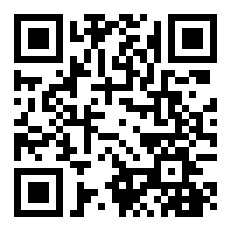

Record 0 Label: 1


In [179]:
# Retrieving first QR code in dataset
record_0 = dataset[0]
print("Record 0 QR Image:")
display(record_0["image"])
print("Record 0 Label:", record_0["label"])

## Data Preprocessing:

In [180]:
# Creating an 80/20 split for training and testing
dataset_split = dataset.train_test_split(
    test_size=0.2,
    seed=42
)

In [181]:
# Defining the training and testing sets
train_dataset = dataset_split["train"]
test_dataset = dataset_split["test"]

In [182]:
print("Samples in Training Set:", train_dataset.num_rows)
print("Samples in Testing Set:", test_dataset.num_rows)

Samples in Training Set: 188629
Samples in Testing Set: 47158


In [183]:
def create_image_processor() -> AutoImageProcessor:
    """ 
    Loads an image processor that prerepares input features for vision models and post processing 
    their outputs by transformations such as resizing, normalization, and conversion to PyTorch 
    and Numpy tensors.
    
    Args:
        None:
        
    Returns:
        AutoImageProcessor: An image processor object
    """
    img_processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
    return img_processor

In [184]:
# Loading the image processor
processor = create_image_processor()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [185]:
def transforms(batch: Dataset) -> dict:
    """
    Transforms raw images to pixel values for vision transformer model.
    
    Args:
        batch: A batch from the dataset containing 'image' and 'label' keys
        
    Returns:
        dict: A dictionary with preprocessed 'pixel_values' and 'labels' keys
    """
    # Converting QR images to RGB format
    images = [x.convert("RGB") for x in batch["image"]]

    # Preprocessing the formatted images for the ViT model
    inputs = processor(images, return_tensors="pt")
    inputs["labels"] = batch["label"]
    
    return inputs

In [186]:
def collate_fn(batch: Dataset) -> dict:
    """
    Takes the individual data samples (dictionaries) provided and combine sthem into a batched
    tensore for effiecient model training.
    
    Args:
        batch: A list of dictionaries containing 'pixel_values' and 'labels' keys
        
    Returns:
        dict: A dictionary with batched 'pixel_values' and 'labels' tensors
    """
    tensors = {"pixel_values": torch.stack([x["pixel_values"] for x in batch]),
               "labels": torch.tensor([x["labels"] for x in batch])}
    
    return tensors

In [187]:
# Saving version of test set with no tranformation applied 
untransformed_test_dataset = Dataset.from_dict(test_dataset.to_dict())

In [188]:
# Applies image preprocessing transfomration on-the-fly when data is loaded
train_dataset.set_transform(transforms)
test_dataset.set_transform(transforms)

In [189]:
# Creating bi-directional label mappings for model configuration
id_to_label = {0: "Phishing", 1: "Legitimate"}
label_to_id = {"Phishing": 0, "Legitimate": 1}

## Loading Fine-Tuned ViT:

In [190]:
# Defining model path
model_path = "M-a-t-t-E/vit-base-qr-classifier"

In [191]:
processor = AutoImageProcessor.from_pretrained(model_path)

In [192]:
# Loading model and setting it to evaluation mode
model = AutoModelForImageClassification.from_pretrained(model_path)
model.eval()

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

## Model Explainablility:

### Grad-CAM:

In [193]:
def reshape_transform(tensor: torch.Tensor, height: int=14, width: int=14) ->  torch.Tensor:
    """
    Reshapes the ViT output tensor to be compatible with Grad-CAM. Separates the class token, reshapes patch
    tokens to a grid, and transposes dimensions.

    Args:
        tensor: The output tensor from the ViT model
        height: The height of the patch grid (default is 14 for ViT-base)
        width: The width of the patch grid (default is 14 for ViT-base)

    Returns:
        torch.Tensor: The reshaped tensor suitable for Grad-CAM
    """
    # Excludes the class token (first token) and reshapes the rest
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    
    # Transposes to (Batch, Channels, Height, Width)
    result = result.transpose(2, 3).transpose(1, 2)
    return result

In [194]:
class HuggingfaceWrapper(torch.nn.Module):
    def __init__(self, model):
        super(HuggingfaceWrapper, self).__init__()
        self.model = model
        
    def forward(self, x):
        # Extract and return only the logits tensor
        return self.model(x).logits

In [195]:
def get_gradcam_visualization(image: Image, model: AutoModelForImageClassification, processor: AutoImageProcessor):
    """
    Generates a Grad-CAM heatmap for a given image using the specified ViT model.

    Args:
        image: The input image for which to generate the heatmap
        model: The trained ViT model
        processor: The image processor for preprocessing the image

    Returns:
        The Grad-CAM heatmap as a NumPy array
    """
    # Preprocess the image
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"]
    
    # Move input tensor to the same device as the model
    device = model.device
    pixel_values = pixel_values.to(device)
    
    wrapped_model = HuggingfaceWrapper(model)
    
    # Define the target layer (pointing to the original model inside the wrapper)
    target_layers = [model.vit.layernorm]
    
    # Initialize GradCAM with the WRAPPED model
    cam = GradCAM(model=wrapped_model, target_layers=target_layers, reshape_transform=reshape_transform)
    
    # Generating the heatmap
    grayscale_cam = cam(input_tensor=pixel_values, targets=None, eigen_smooth=True)
    
    return grayscale_cam[0, :]

In [196]:
def visualize_gradcam_samples(dataset: Dataset, model: AutoModelForImageClassification, processor: AutoImageProcessor, id_to_label: dict, n_samples: int=3):
    """
    Visualizes Grad-CAM explanations for random samples from the dataset.

    Args:
        dataset: The dataset containing images and labels
        model: The trained ViT model
        processor: The image processor for preprocessing images
        id_to_label: Dictionary mapping label IDs to label names
        num_samples: Number of samples to visualize from each class (default is 3)
    Returns:
        None
    """
    # Selecting random indices for each class
    phishing_indices = [i for i in range(len(dataset)) if dataset[i]['label'] == 0]
    legitimate_indices = [i for i in range(len(dataset)) if dataset[i]['label'] == 1]
    
    # Selecting n samples
    selected_phishing = np.random.choice(phishing_indices, n_samples, replace=False)
    selected_legitimate = np.random.choice(legitimate_indices, n_samples, replace=False)
    
    # Combining and shuffling
    indices_to_plot = np.concatenate([selected_phishing, selected_legitimate])
    np.random.shuffle(indices_to_plot)

    for idx in indices_to_plot:
        # Accessing image and label
        sample = dataset[int(idx)]
        image = Image.open(sample["image"]["path"]).convert("RGB")
        true_label_id = sample["label"]
        
        image_resized = image.resize((224, 224))
        
        # Convert and normalize [0, 1]
        img_np = np.array(image_resized)
        img_normalized = img_np.astype(np.float32) / 255.0
        
        # Generate Grad-CAM heatmap
        heatmap = get_gradcam_visualization(image_resized, model, processor)
        
        # Create overlay
        visualization = show_cam_on_image(img_normalized, heatmap, use_rgb=True)
        
        # Determine model prediction
        inputs = processor(images=image_resized, return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            pred_label_id = torch.argmax(outputs.logits, dim=1).item()
            
        # Display
        true_label = id_to_label[true_label_id]
        pred_label = id_to_label[pred_label_id]
        
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        
        axes[0].imshow(image_resized)
        axes[0].set_title(f"Original Image\nTrue: {true_label}")
        axes[0].axis('off')
        
        axes[1].imshow(visualization)
        axes[1].set_title(f"Grad-CAM Overlay\nPred: {pred_label}")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()

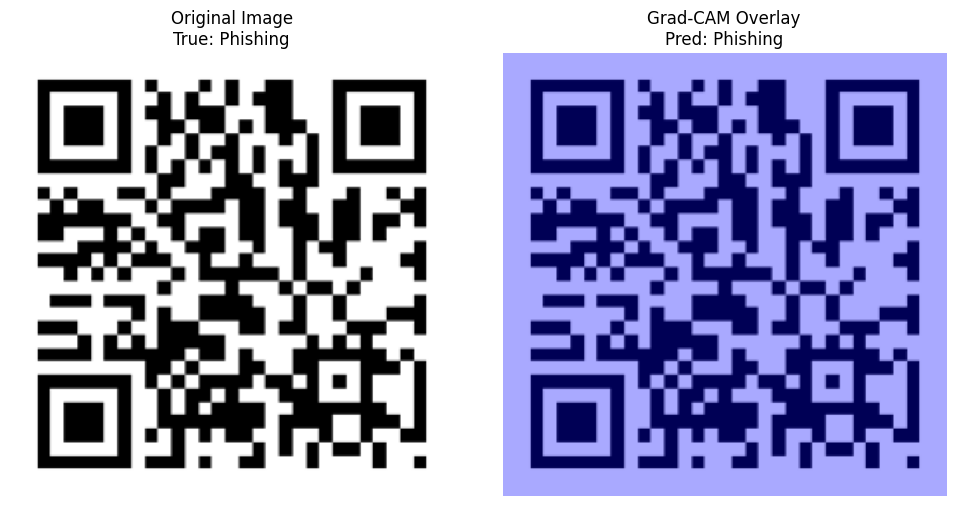

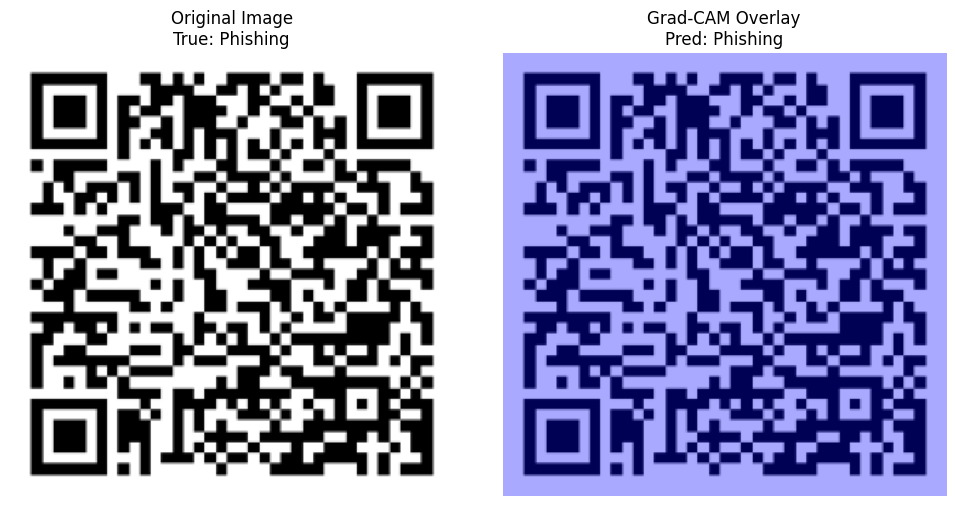

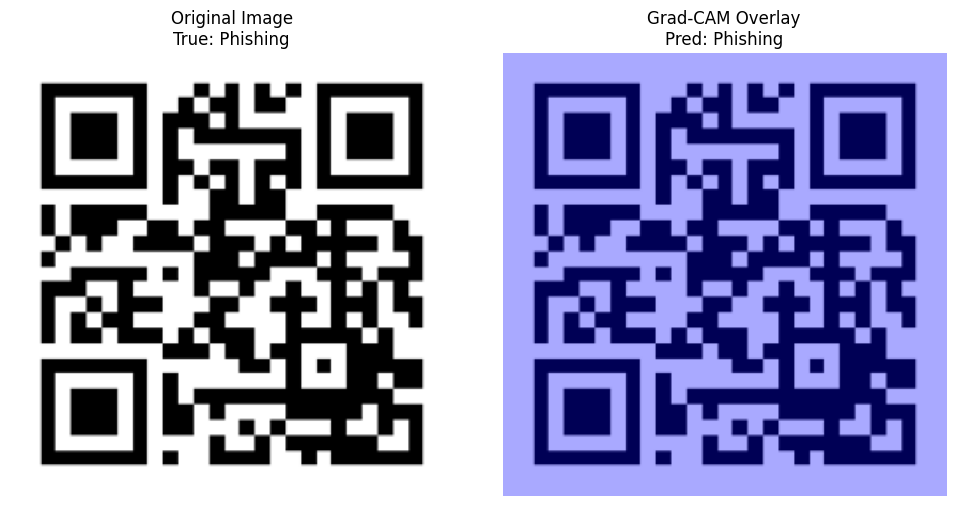

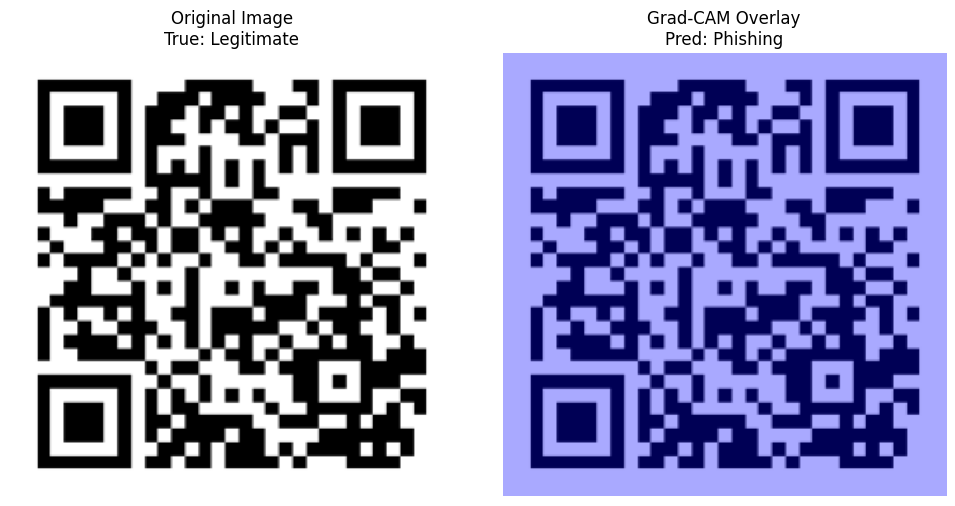

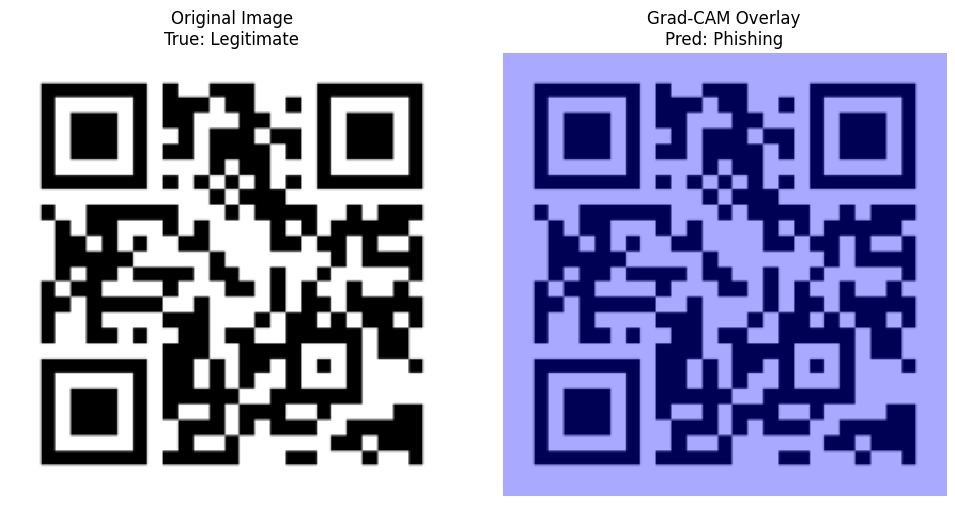

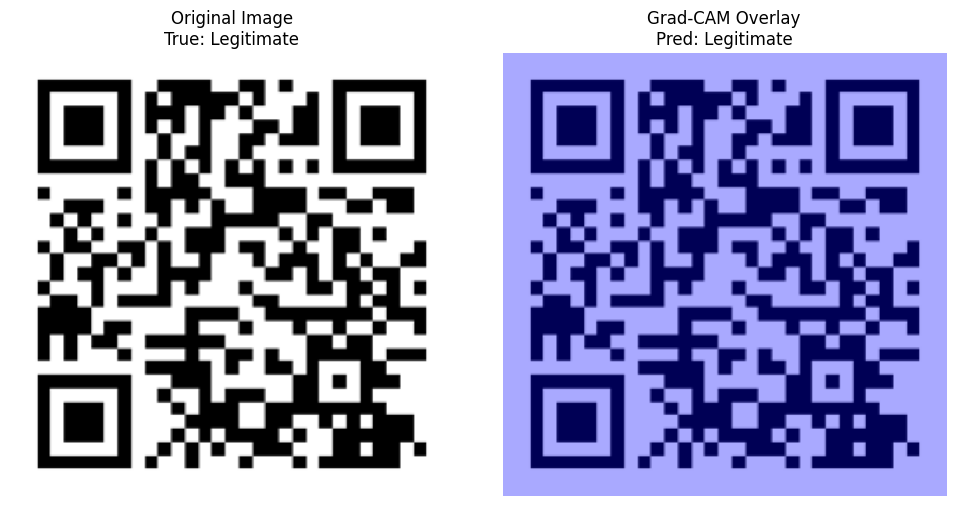

In [197]:
visualize_gradcam_samples(untransformed_test_dataset, model, processor, id_to_label, n_samples=3)

### Attention Rollout:

In [198]:
def get_attention_rollout(model: AutoModelForImageClassification, pixel_values: torch.Tensor, discard_ratio: float=0.9) -> torch.Tensor:
    """
    Computes attention rollout for a ViT model by recursively multiplying attention matrices across all 
    layers while discarding low attention values.
    
    Args:
        model: The fine-tuned ViT model
        pixel_values: Preprocessed input tensor
        discard_ratio: Ratio of attention to discard (defaults to 0.9)
        
    Returns:
        torch.Tensor: Attention rollout matrix
    """
    # Getting attention weights from all layers
    with torch.no_grad():
        outputs = model(pixel_values, output_attentions=True)
        attentions = outputs.attentions 
        
    # Checkcking if attentions were returned
    if attentions is None:
        raise ValueError("Model did not return attention weights. Ensure output_attentions=True is supported.")
    
    # Averaging attention heads for each layer
    attention_matrices = []
    for attention in attentions:
        avg_attention = attention.mean(dim=1)
        attention_matrices.append(avg_attention)
    
    # Initializing rollout with identity matrix
    batch_size, seq_len = attention_matrices[0].shape[:2]
    rollout = torch.eye(seq_len).unsqueeze(0).repeat(batch_size, 1, 1)
    rollout = rollout.to(attention_matrices[0].device)
    
    # Applying attention rollout recursively
    for attention_matrix in attention_matrices:
        # Addding residual connection
        attention_matrix = attention_matrix + torch.eye(seq_len).to(attention_matrix.device)
        # Re-normalizing
        attention_matrix = attention_matrix / attention_matrix.sum(dim=-1, keepdim=True)
        # Applyng discard ratio to keep only top attention values
        if discard_ratio > 0:
            
            flat_attention = attention_matrix.view(batch_size, -1)
            _, indices = torch.topk(flat_attention, int(flat_attention.size(-1) * (1 - discard_ratio)), dim=-1)
            
            # Creating mask
            mask = torch.zeros_like(flat_attention)
            mask.scatter_(-1, indices, 1)
            mask = mask.view_as(attention_matrix)
            
            attention_matrix = attention_matrix * mask
            # Re-normalizing after masking
            attention_matrix = attention_matrix / attention_matrix.sum(dim=-1, keepdim=True)
        
        # Multiplying with rollout
        rollout = torch.bmm(attention_matrix, rollout)
    
    return rollout

In [199]:
def visualize_attention_rollout(image: Image, model: AutoModelForImageClassification, processor: AutoImageProcessor, patch_size: int=16) -> np.ndarray:
    """
    Visualizes attention rollout for a given image.
    
    Args:
        image: PIL Image
        model: The ViT model
        processor: Image processor
        patch_size: Patch size used by the model (default 16)
        
    Returns:
        numpy.ndarray: Attention map
    """
    # Preprocessing image
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(model.device)
    
    # Getting attention rollout
    rollout = get_attention_rollout(model, pixel_values)
    
    # Extracting attention for patches, excluding CLS token
    patch_attention = rollout[0, 0, 1:]
    
    # Reshaping to spatial dimensions
    grid_size = int(np.sqrt(len(patch_attention)))
    attention_map = patch_attention.reshape(grid_size, grid_size).cpu().numpy()
    
    # Resizing to match image size
    scale_factor = 224 // (grid_size * patch_size) * patch_size
    if scale_factor != 1:
        attention_map = zoom(attention_map, scale_factor, order=1)
    
    # Normalizing
    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())
    
    return attention_map

In [200]:
def visualize_attention_rollout_samples(dataset: Dataset, model: AutoModelForImageClassification, processor: AutoImageProcessor, id_to_label: dict, n_samples: int=3) -> None:
    """
    Visualizes attention rollout explanations for random samples from the dataset.
    
    Args:
        dataset: The untransformed dataset containing images and labels
        model: The trained ViT model
        processor: The image processor
        id_to_label: Dictionary mapping label IDs to label names
        n_samples: Number of samples to visualize from each class
        
    Returns:
        None:
    """
    # Ensuring correct model configuration
    model.config._attn_implementation = "eager"
    model.config.output_attentions = True
    model.config.output_attentions = True
    
    # Selecting random indices for each class
    phishing_indices = [i for i in range(len(dataset)) if dataset[i]['label'] == 0]
    legitimate_indices = [i for i in range(len(dataset)) if dataset[i]['label'] == 1]
    
    selected_phishing = np.random.choice(phishing_indices, n_samples, replace=False)
    selected_legitimate = np.random.choice(legitimate_indices, n_samples, replace=False)
    
    # Concatenating and shuffling the selected phishing and leigitimate samples
    indices_to_plot = np.concatenate([selected_phishing, selected_legitimate])
    np.random.shuffle(indices_to_plot)

    for idx in indices_to_plot:
        # Accessing image and label
        sample = dataset[int(idx)]
        image = Image.open(sample["image"]["path"]).convert("RGB")
        true_label_id = sample["label"]
        
        image_resized = image.resize((224, 224))
        
        # Generating attention rollout
        attention_map = visualize_attention_rollout(image_resized, model, processor)
        
        # Creating overlay
        img_np = np.array(image_resized).astype(np.float32) / 255.0
        
        # Creating heatmap overlay
        heatmap = cm.jet(attention_map)[:, :, :3]
        overlay = 0.6 * img_np + 0.4 * heatmap
        
        # Getting model prediction
        inputs = processor(images=image_resized, return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            pred_label_id = torch.argmax(outputs.logits, dim=1).item()
        
        true_label = id_to_label[true_label_id]
        pred_label = id_to_label[pred_label_id]
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].imshow(image_resized)
        axes[0].set_title(f"Original Image\nTrue: {true_label}")
        axes[0].axis('off')
        
        axes[1].imshow(attention_map, cmap='jet')
        axes[1].set_title("Attention Rollout")
        axes[1].axis('off')
        
        axes[2].imshow(overlay)
        axes[2].set_title(f"Overlay\nPred: {pred_label}")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


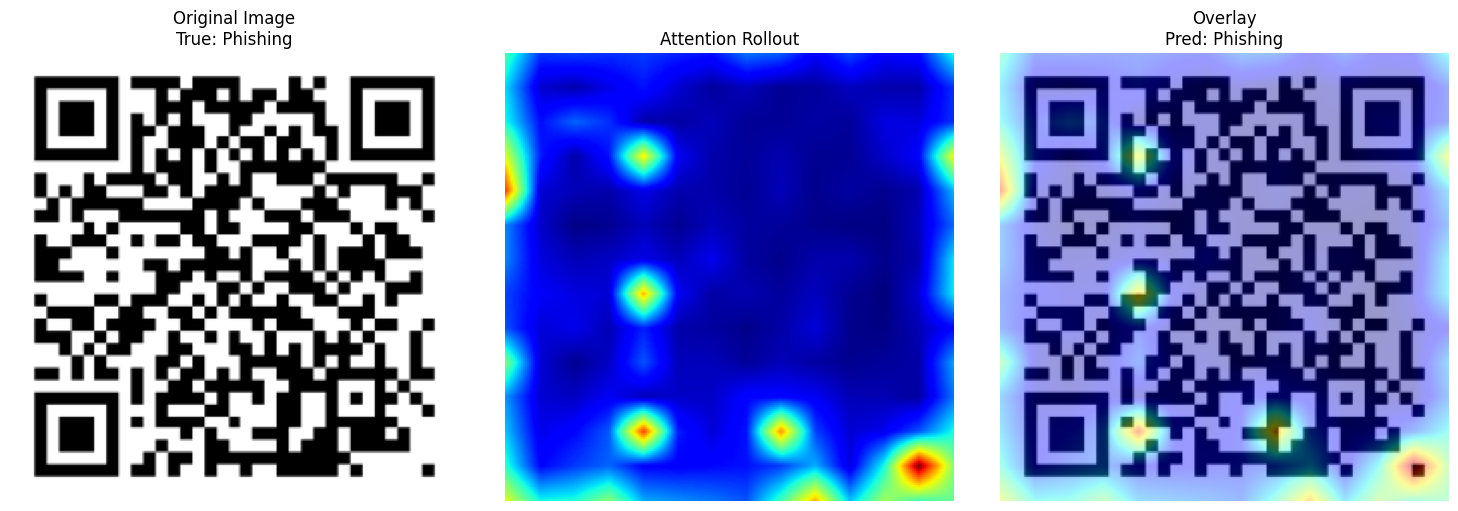

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


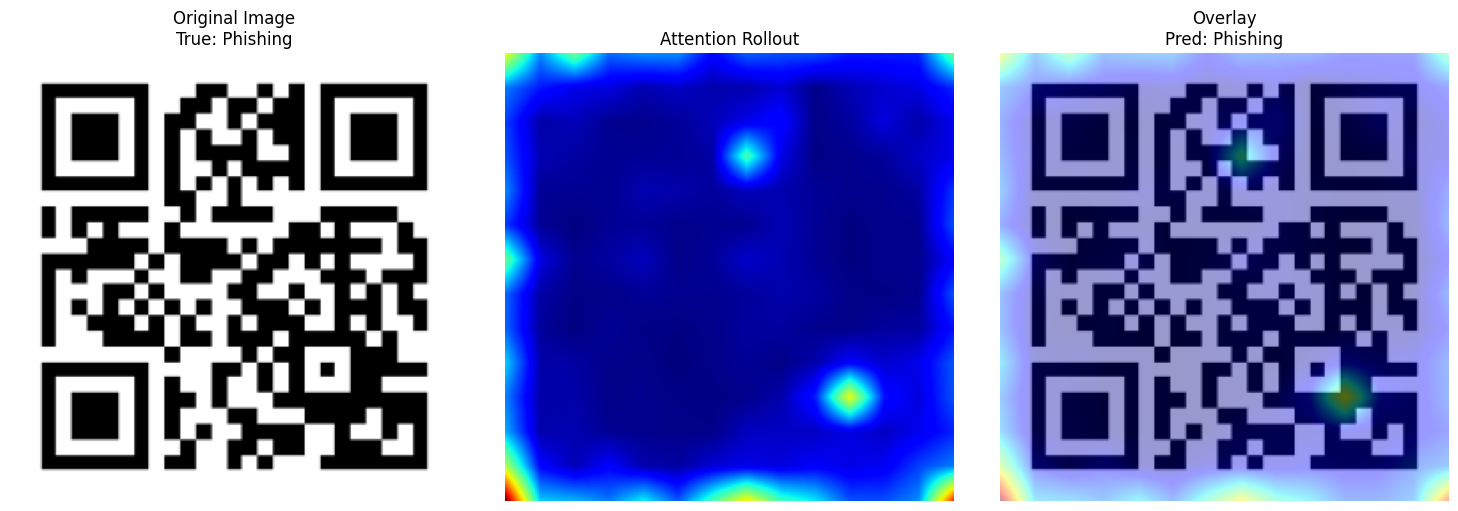

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


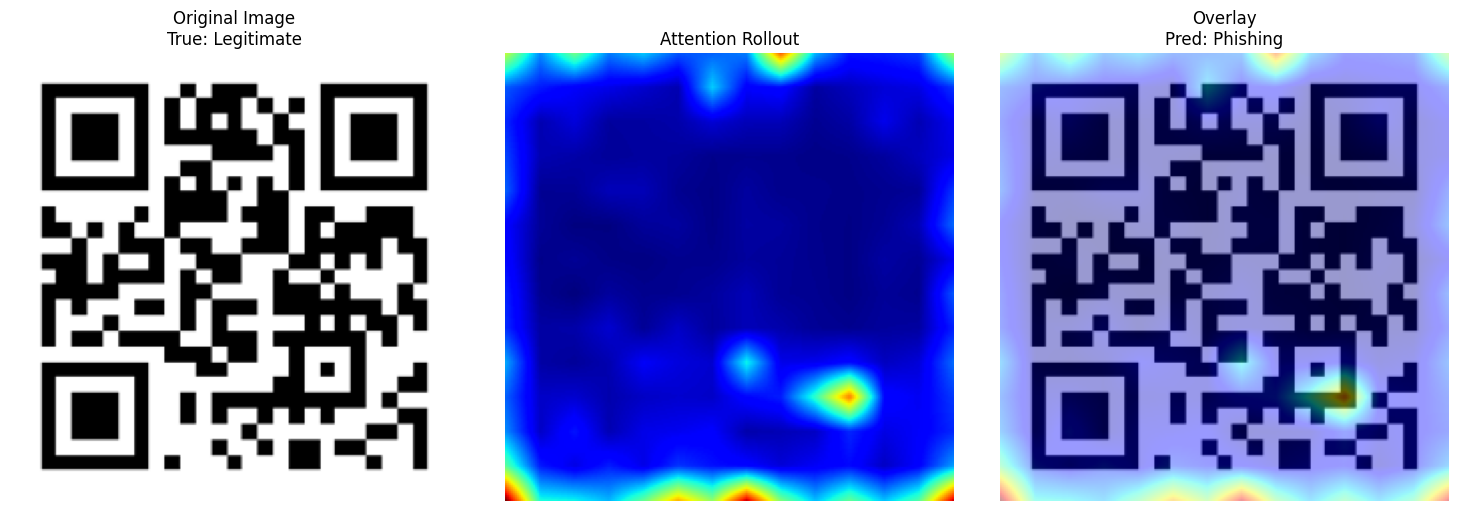

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


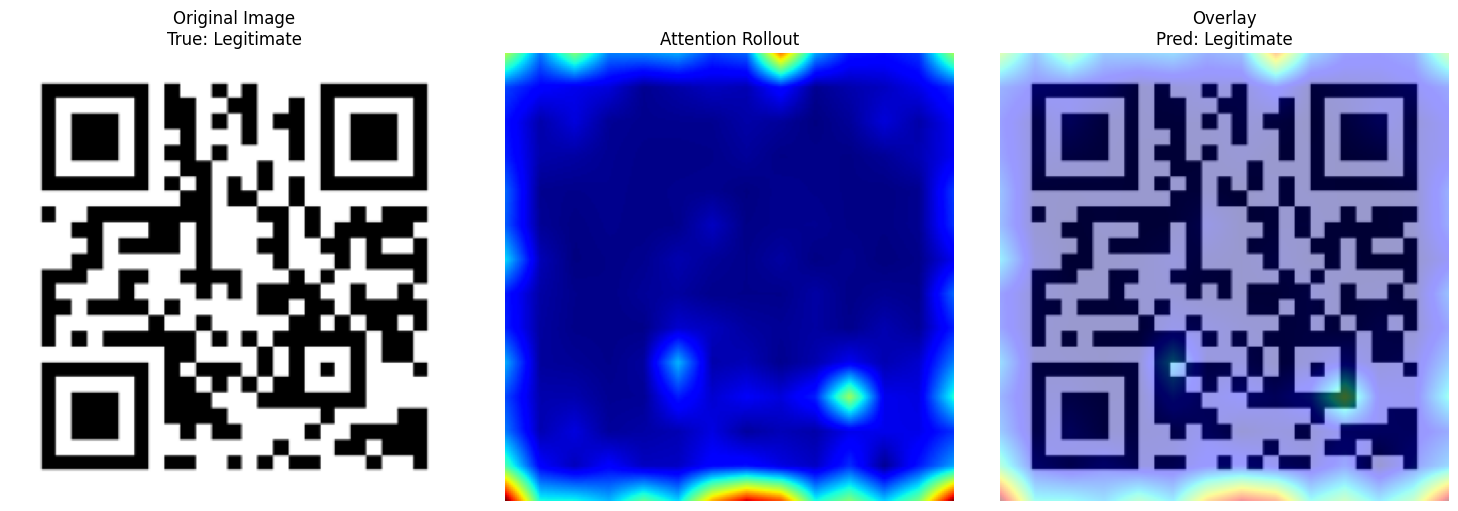

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


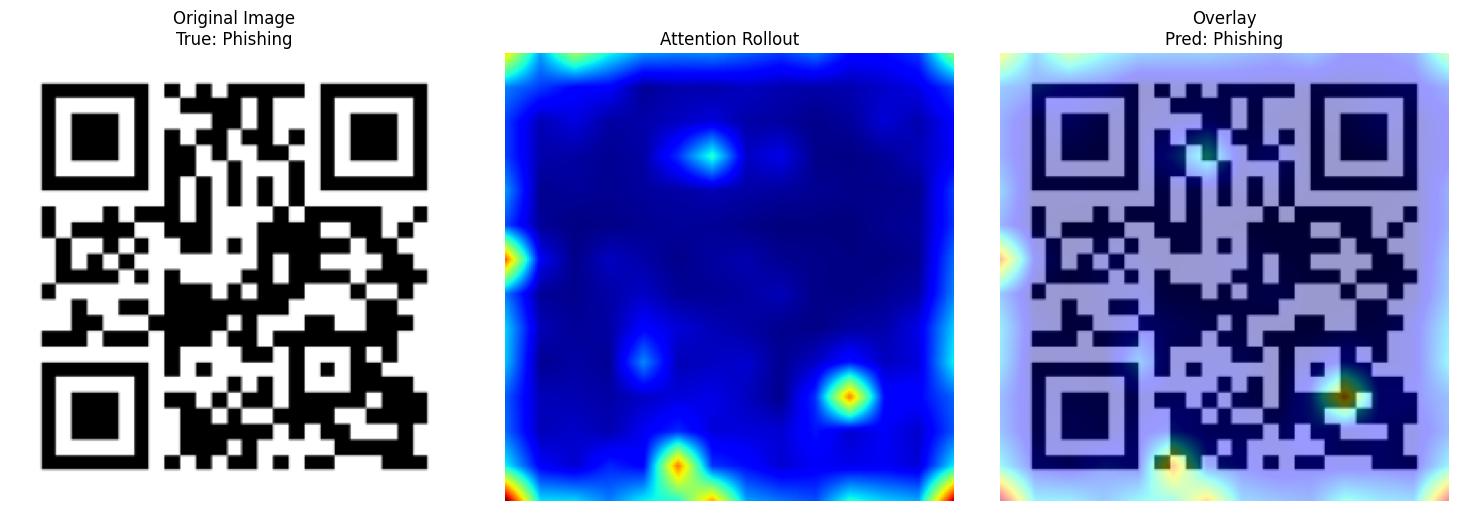

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


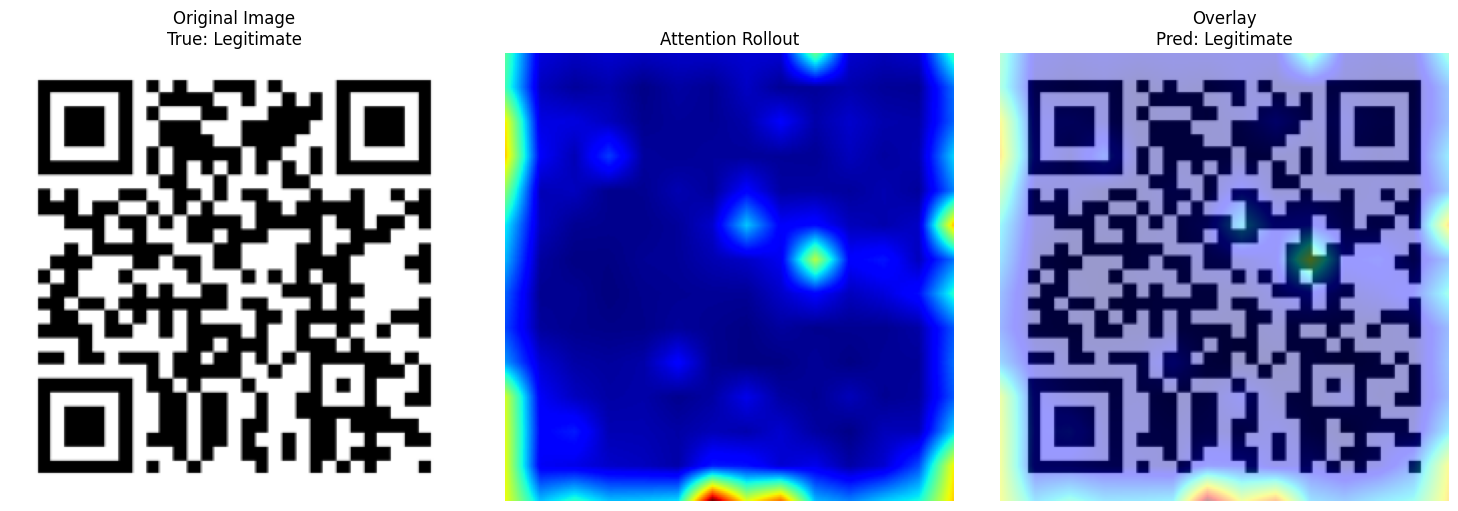

In [208]:
visualize_attention_rollout_samples(untransformed_test_dataset, model, processor, id_to_label)